# BirdCLEF+ 2026 — Data Exploration

Metadata EDA for the training set.


In [1]:
from google.colab import drive
drive.mount("/content/drive")
%run colab_init.py

!pip install -q pandas matplotlib seaborn kaggle

from birdclef.colab import mount_and_configure, set_kaggle_token
from birdclef.paths import FIGURES_DIR, METADATA_DIR, TAXONOMY_CSV, TRAIN_CSV

mount_and_configure()
set_kaggle_token()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)



Mounted at /content/drive
Working directory: /content/drive/MyDrive/BirdCLEF_Project/repro


In [ ]:
import ast
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from birdclef.paths import FIGURES_DIR, METADATA_DIR, TAXONOMY_CSV

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train_csv = METADATA_DIR / "train.csv"
df = pd.read_csv(train_csv)
print(f"Loaded {len(df)} rows from {train_csv}")



Loaded 35549 rows from /content/train.csv


## Dataset overview


In [ ]:
print(df.shape)
print(df.columns.tolist())
print(df.head())


(35549, 15)
['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']
  primary_label secondary_labels type  latitude  longitude scientific_name  \
0       1161364               []   []  -22.7562   -46.8666    Guyalna cuta   
1       1161364               []   []  -22.7558   -46.8700    Guyalna cuta   
2       1161364               []   []  -22.7547   -46.8728    Guyalna cuta   
3       1161364               []   []  -22.7547   -46.8728    Guyalna cuta   
4       1161364               []   []  -22.7426   -46.8985    Guyalna cuta   

    common_name class_name  inat_taxon_id         author   license  rating  \
0  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
1  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
2  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   
3  Guya

## Taxonomic composition


In [ ]:
from pathlib import Path

# adjust path to where your CSVs live on Colab/Drive
data_dir = Path("/content")  # or BirdCLEF_Project on Drive

tax = pd.read_csv(TAXONOMY_CSV)
df["grp"] = df.primary_label.astype(str).map(
    dict(zip(tax.primary_label.astype(str), tax.class_name))
)

by = df.groupby("grp").agg(
    recordings=("primary_label", "size"),
    species=("primary_label", "nunique"),
print(by.sort_values("recordings", ascending=False).to_string())

          recordings  species
grp                          
Aves           34799      162
Amphibia         451       32
Insecta          199        3
Mammalia          99        8
Reptilia           1        1


## Zero-shot scored classes


In [ ]:
# finds the classes that have no audio in the training set.
train_sp = set(df.primary_label.astype(str))
sample_path = METADATA_DIR / "sample_submission.csv"
if not sample_path.exists():
    from birdclef.paths import SAMPLE_SUBMISSION_CSV
    sample_path = SAMPLE_SUBMISSION_CSV
if sample_path.exists():
    scored = set(pd.read_csv(sample_path).columns[1:])
    missing = sorted(scored - train_sp)
    print(f"Scored classes without training audio: {len(missing)}")
    print(missing[:20])


Scored classes without training audio: 28
['1491113', '25073', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18']


## Source split


In [ ]:
print(df.collection.value_counts().to_string())


collection
XC      23043
iNat    12506


## Class imbalance


classes with <5 recordings: 14 of 206
classes with <10 recordings: 25 of 206
classes with <25 recordings: 39 of 206
classes with <50 recordings: 52 of 206
classes with <100 recordings: 82 of 206
imbalance ratio max/min = 499/1 = 499x


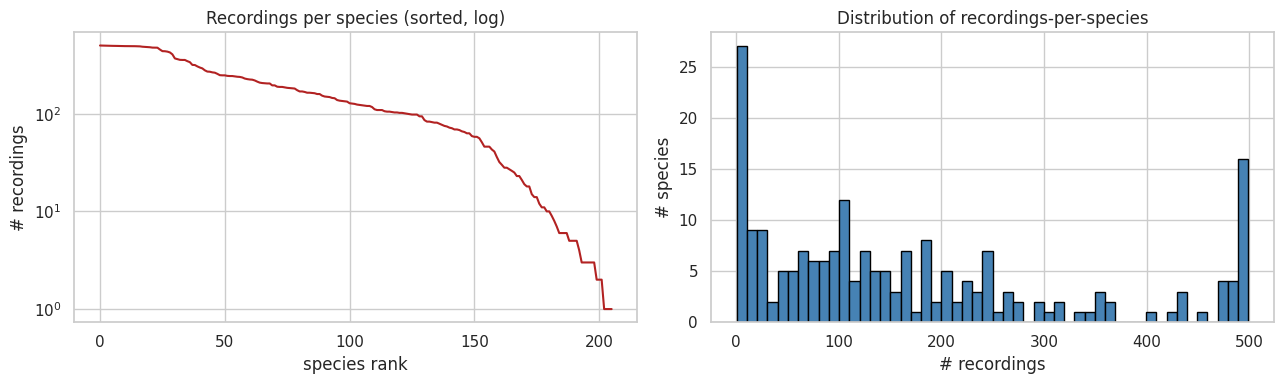

In [25]:
# Visualizing the class imbalances of the dataset
vc = df.primary_label.value_counts()
for thr in (5,10,25,50,100):
    print(f"classes with <{thr} recordings: {(vc<thr).sum()} of {len(vc)}")
print(f"imbalance ratio max/min = {vc.max()}/{vc.min()} = {vc.max()/max(vc.min(),1):.0f}x")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(len(vc)), vc.values, color='firebrick'); ax[0].set_yscale('log')
ax[0].set_title('Recordings per species (sorted, log)'); ax[0].set_xlabel('species rank'); ax[0].set_ylabel('# recordings')
ax[1].hist(vc.values, bins=50, color='steelblue', edgecolor='black')
ax[1].set_title('Distribution of recordings-per-species'); ax[1].set_xlabel('# recordings'); ax[1].set_ylabel('# species')
plt.tight_layout(); plt.show()

## Secondary labels


In [ ]:
# to determine which of the recordings have a second vocalizer and as such
# the proportion of records that more accurately mimic the PAM setting
def parse_list(x):
    if pd.isna(x) or x == "[]":
        return []
    return ast.literal_eval(x)

df["n_sec"] = df.secondary_labels.apply(lambda x: len(parse_list(x)))
print(df["n_sec"].value_counts().sort_index().to_string())


n_sec
0     31177
1      2623
2      1049
3       379
4       169
5        87
6        35
7        11
8        12
9         1
10        2
11        1
12        2
15        1


## Geography


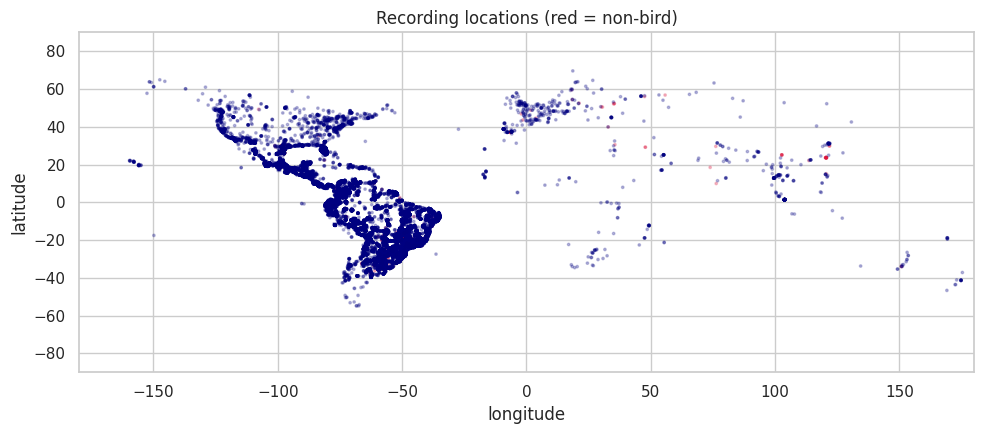

100.0% of recordings have coordinates


In [ ]:
plt.figure(figsize=(10,4.5))
plt.scatter(df.longitude, df.latitude, s=3, alpha=0.25, c=(df.grp=='Aves').map({True:'navy',False:'crimson'}))
plt.title('Recording locations (red = non-bird)'); plt.xlabel('longitude'); plt.ylabel('latitude')
plt.xlim(-180,180); plt.ylim(-90,90)
plt.tight_layout(); plt.show()
print(f"{df.latitude.notna().mean()*100:.1f}% of recordings have coordinates")

## Author concentration


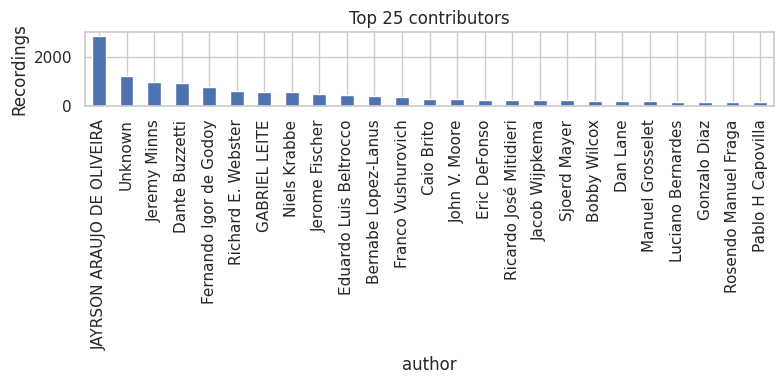

In [ ]:
a = df.author.value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
a.head(25).plot(kind="bar", ax=ax)
ax.set_title("Top 25 contributors")
ax.set_ylabel("Recordings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "author_concentration.png", dpi=200)
plt.show()


In [ ]:
# pick the most-recorded species in each group (most likely a clean example) + one rare bird
picks = []
for grp in ['Aves','Insecta','Amphibia','Mammalia']:
    sg = df[df.grp==grp]
    if not len(sg): continue
    top = sg.primary_label.value_counts().idxmax()
    picks.append(sg[sg.primary_label==top].sort_values('rating', ascending=False).iloc[0])
rare_bird = df[df.grp=='Aves'].primary_label.value_counts().idxmin()
picks.append(df[df.primary_label==rare_bird].iloc[0])
picks = pd.DataFrame(picks).reset_index(drop=True)
picks[['primary_label','common_name','grp','rating','collection','filename']]

,primary_label,common_name,grp,rating,collection,filename
0,rubthr1,Rufous-bellied Thrush,Aves,5.0,XC,rubthr1/XC620672.ogg
1,244024,Giant Cicada,Insecta,0.0,iNat,244024/iNat269695.ogg
2,22973,Whistling Grass Frog,Amphibia,5.0,XC,22973/XC892927.ogg
3,47144,Domestic Dog,Mammalia,5.0,XC,47144/XC993966.ogg
4,sptnig1,Spot-tailed Nightjar,Aves,0.0,iNat,sptnig1/iNat483063.ogg


In [ ]:
# download just these files (small)
import glob
AUDIO_DIR = os.path.join(DATA, 'audio_samples'); os.makedirs(AUDIO_DIR, exist_ok=True)
for fn in picks.filename:
    base = os.path.basename(fn)
    if glob.glob(os.path.join(AUDIO_DIR, '**', base), recursive=True): continue
    !kaggle competitions download -c birdclef-2026 -f train_audio/{fn} -p {AUDIO_DIR}
for z in glob.glob(os.path.join(AUDIO_DIR, '*.zip')):
    with zipfile.ZipFile(z) as zf: zf.extractall(AUDIO_DIR)
    os.remove(z)
print('downloaded:', glob.glob(os.path.join(AUDIO_DIR, '**', '*.ogg'), recursive=True))

100% 838k/838k [00:00<00:00, 2.33MB/s]

100% 265k/265k [00:00<00:00, 1.18MB/s]

100% 347k/347k [00:00<00:00, 1.50MB/s]

100% 109k/109k [00:00<00:00, 864kB/s]

100% 219k/219k [00:00<00:00, 1.16MB/s]

downloaded: ['/content/drive/MyDrive/BirdCLEF_Project/repro/data/audio_samples/XC620672.ogg', '/content/drive/MyDrive/BirdCLEF_Project/repro/data/audio_samples/iNat269695.ogg', '/content/drive/MyDrive/BirdCLEF_Project/repro/data/audio_samples/XC892927.ogg', '/content/drive/MyDrive/BirdCLEF_Project/repro/data/audio_samples/XC993966.ogg', '/content/drive/MyDrive/BirdCLEF_Project/repro/data/audio_samples/iNat483063.ogg']


### Rufous-bellied Thrush  ·  *Aves*  ·  rating 5.0  ·  XC

NameError: name 'savefig' is not defined

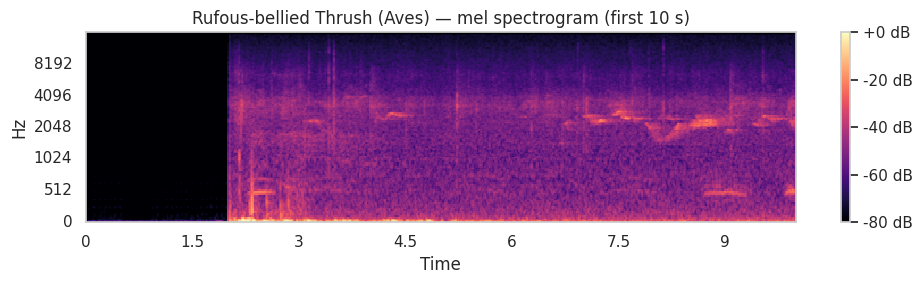

In [ ]:
import librosa, librosa.display
from IPython.display import Audio, display, Markdown

def find_audio(fn):
    hits = glob.glob(os.path.join(AUDIO_DIR, '**', os.path.basename(fn)), recursive=True)
    return hits[0] if hits else None

for _, r in picks.iterrows():
    display(Markdown(f"### {r.common_name}  ·  *{r.grp}*  ·  rating {r.rating}  ·  {r.collection}"))
    path = find_audio(r.filename)
    if not path:
        print('  (clip not downloaded)'); continue
    y, sr = librosa.load(path, sr=32000, duration=10.0, mono=True)
    display(Audio(y, rate=sr))
    S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=sr//2), ref=np.max)
    plt.figure(figsize=(10,3))
    librosa.display.specshow(S, sr=sr, x_axis='time', y_axis='mel', fmax=sr//2, cmap='magma')
    plt.colorbar(format='%+2.0f dB'); plt.title(f"{r.common_name} ({r.grp}) — mel spectrogram (first 10 s)")
    plt.tight_layout(); savefig(f"spec_{r.grp}_{r.primary_label}.png"); plt.show()